# HW 6

### 1(c)

In [1]:
using LinearAlgebra, Plots, IterativeSolvers

"""
from Prof. Haddock's notes at
https://jamiehaddock.com/164-ScientificComputing/Lecture24/Lecture24.html

    arnoldi(A,u,m)

Perform the Arnoldi iteration for `A` starting with vector `u`, out
to the Krylov subspace of degree `m`. Returns the orthonormal basis
(`m`+1 columns) and the upper Hessenberg `H` of size `m`+1 by `m`.
"""
function arnoldi(A,u,m)
    n = length(u)
    Q = zeros(n,m+1)
    H = zeros(m+1,m)
    Q[:,1] = u/norm(u)
    for j in 1:m
        # Find the new direction that extends the Krylov subspace.
        v = A*Q[:,j]
        # Remove the projections onto the previous vectors.
        for i in 1:j
            H[i,j] = dot(Q[:,i],v)
            v -= H[i,j]*Q[:,i]
        end
        # Normalize and store the new basis vector.
        H[j+1,j] = norm(v)
        Q[:,j+1] = v/H[j+1,j]
    end
    return Q,H
end

arnoldi

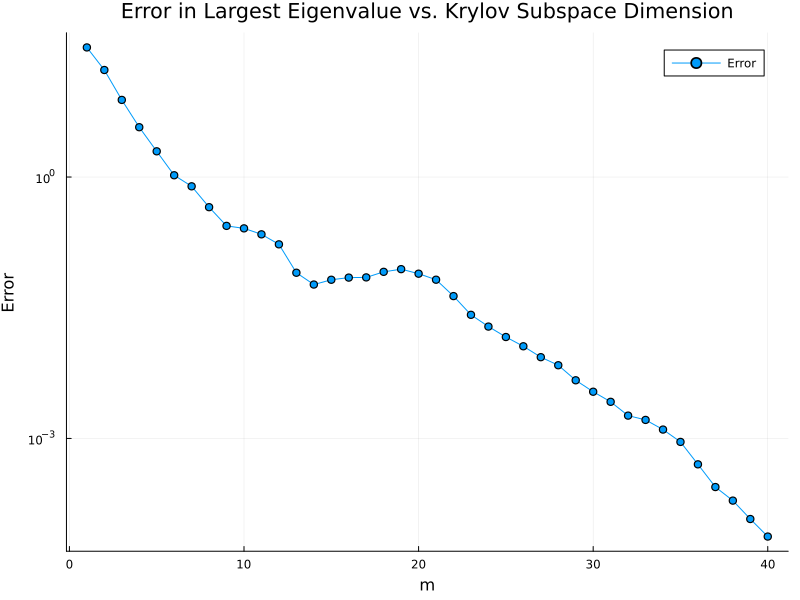

In [2]:
# set up the matrix
λ = @. 10 + (1:100)
A = triu(rand(100,100),1) + diagm(λ)
u = rand(100)

# perform the Arnoldi iteration
Q,H = arnoldi(A,u,40)

# Compute eigenvalues of H_m for m = 1 to 40
errors = Float64[]
for m in 1:40
    # Get eigenvalues of H_m (upper m×m portion of H)
    H_m = H[1:m, 1:m]
    λ_H = eigvals(H_m)
    
    # Find largest eigenvalue in magnitude
    max_λ_H = maximum(abs.(λ_H))
    
    # Compute error with largest eigenvalue of A (which is 110)
    error = abs(max_λ_H - 110)
    push!(errors, error)
end

# Create log-linear plot
plot(1:40, errors, size=(800,600),
     yscale=:log10,
     xlabel="m",
     ylabel="Error",
     title="Error in Largest Eigenvalue vs. Krylov Subspace Dimension",
     label="Error",
     marker=:circle)



### 2(b)

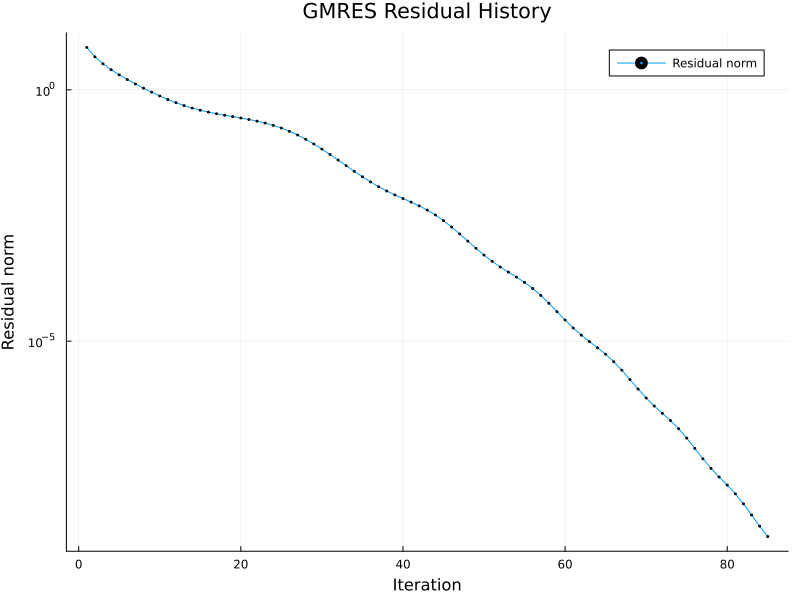

In [18]:
# Create the matrices
B = diagm(1:100)
Z = zeros(100, 100)
b = ones(200)

# Construct A as a block matrix
A = [B I; Z B]

# Apply GMRES with tolerance 1e-10 for 100 iterations
x, history = IterativeSolvers.gmres(A, b;restart = 100,reltol=1e-10, maxiter=100, log=true)

# Plot the residual history
plot(history[:resnorm], yaxis=:log, label="Residual norm", 
     xlabel="Iteration", ylabel="Residual norm",
     title="GMRES Residual History",
     marker=:circle, markersize=1,
     size=(800,600))


### 2(c)

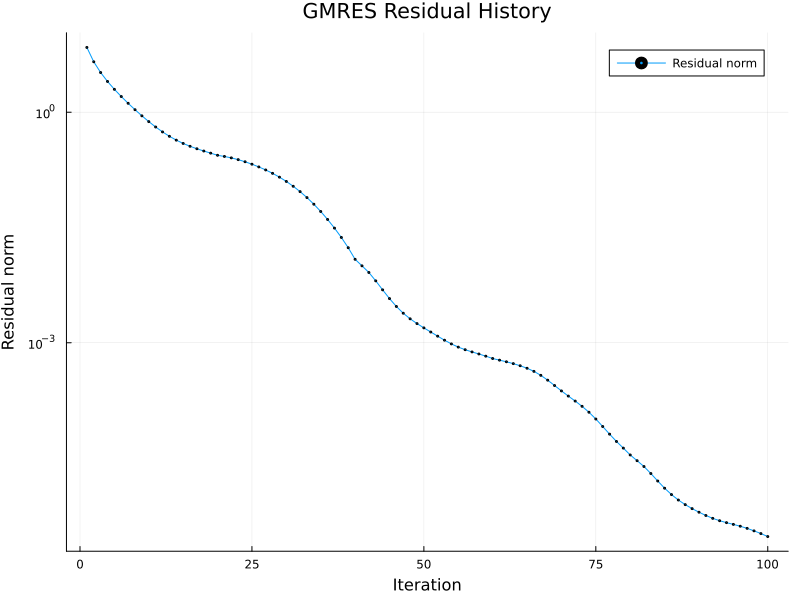

In [16]:
# repeat with restart every 20 iterations
x1, history1 = gmres(A, b; restart=20, reltol=1e-10, maxiter=100, log=true)

# Plot the residual history
plot(history1[:resnorm], yaxis=:log, label="Residual norm", 
     xlabel="Iteration", ylabel="Residual norm",
     title="GMRES Residual History",
     marker=:circle, markersize=1,
     size=(800,600))

### 2(e)

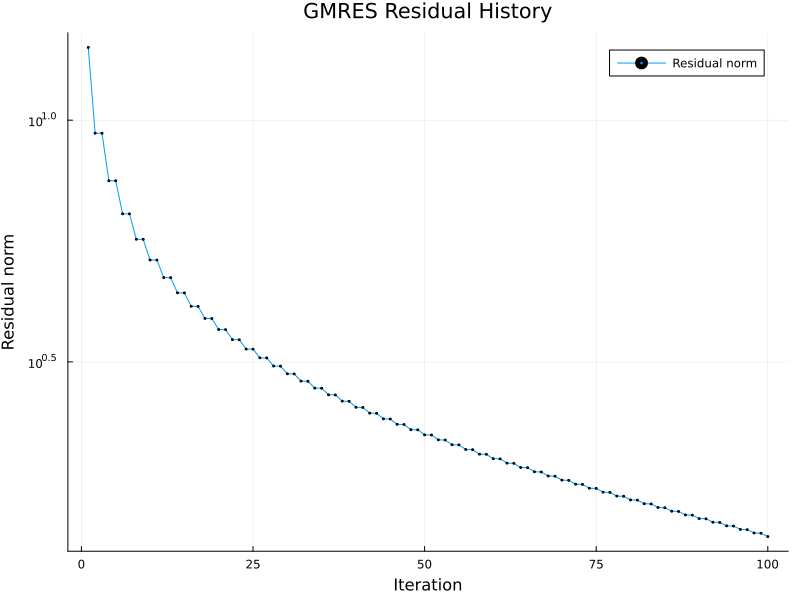

In [20]:
A = [B I; Z -B]

# repeat part (b)
x, history = IterativeSolvers.gmres(A, b;restart = 100,reltol=1e-10, maxiter=100, log=true)

# Plot the residual history
plot(history[:resnorm], yaxis=:log, label="Residual norm", 
     xlabel="Iteration", ylabel="Residual norm",
     title="GMRES Residual History",
     marker=:circle, markersize=1,
     size=(800,600))

This one is more difficult since it converges much slower (or does it converge at all?).